In [1]:
import polars as pl
import sys
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

repo_root = Path.cwd()
while not (repo_root / "pyproject.toml").exists() and repo_root != repo_root.parent:
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from project.helpers import init_client
from project.cl_model import (
    prepare_data,
    corr_matrix,
    cov_matrix,
    fit_ols,
    plot_heatmap,
)


<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute


In [2]:
start = "2015-01-01"
end = "2025-11-01"
client = init_client()

data = prepare_data(start=start, end=end, client=client, target_delta=0.25) # constant_targets
term_structure_cols = ["slope_m1_m2", "slope_const_21_42"]
skew_cols= ["skew_25d", "iv_25c", "iv_25p"]

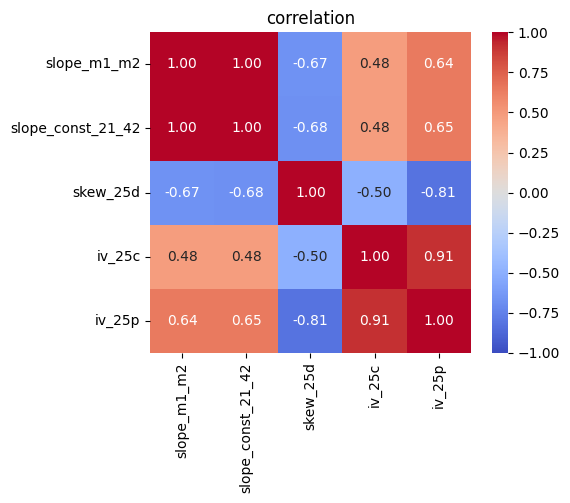

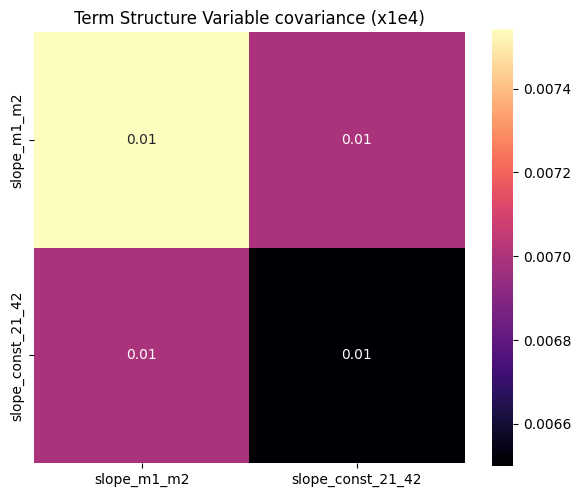

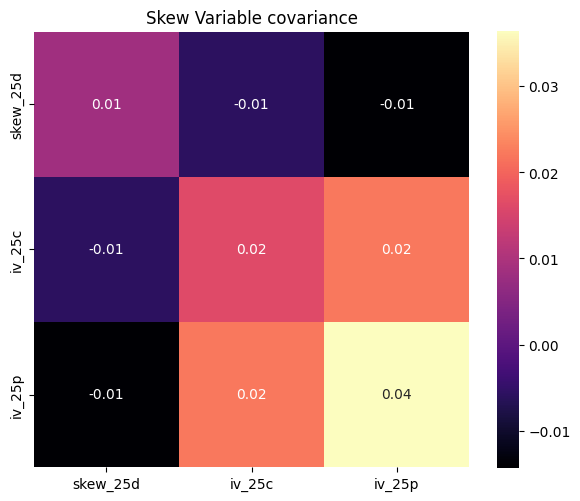

In [3]:
# correlation heatmap
plot_heatmap(data, cols=term_structure_cols + skew_cols, title="correlation", vmin=-1, vmax=1)

# covariance heatmap
cov = data[term_structure_cols].cov() * 1e4
plot_heatmap(data, matrix=cov, title=f"Term Structure Variable covariance (x1e4)", vmin=None, vmax=None, cmap="magma")

cov = data[skew_cols].cov()
plot_heatmap(data, matrix=cov, title=f"Skew Variable covariance", vmin=None, vmax=None, cmap="magma")


## Regression

In [4]:
ols_res = fit_ols(data.dropna(subset=["skew_25d", "slope_m1_m2"]), "skew_25d", ["slope_m1_m2"])

In [5]:
ols_res

{'intercept': np.float64(-0.06273868924702226),
 'r2': np.float64(0.4445733138389415),
 'slope_m1_m2': np.float64(-70.42909998917035)}

- r-square is not too good, and given that there is not a super high correlation, the term structure is a meaningful but not exclusive driver of skew. This actually sets up the need for regressions and maybe some additional controls.